# Phase 4 — Audio Pipeline (Voiceprint)

**Owner:** Audio Lead · **Branch:** `phase-4-audio-pipeline`

This notebook is the *visual* half of Phase 4. The reproducible logic lives in
`scripts/audio_features.py` (feature extraction) and `scripts/train_voice_model.py`
(model). Here we **listen with our eyes**: for every member's clips we plot the
waveform and spectrogram, show what augmentation does, and preview the feature table.

Rubric targets: *Audio Quality & Visualization* (waveform + spectrogram, interpreted)
and *Audio Augmentation & Feature Extraction* (>=2 augmentations, MFCCs + roll-off +
energy saved to `audio_features.csv`).

## 1. Setup

We import the shared functions from `scripts/` so the notebook and the script can
never drift apart.

In [1]:
import sys
from pathlib import Path

import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))
from audio_features import (
    MEMBERS, SR, load_clip, augment, extract_features,
    FEATURE_COLUMNS, detect_phrase,
)

AUDIO_DIR = ROOT / 'audio_data'
clips = sorted(p for p in AUDIO_DIR.glob('*/*.wav') if '_aug_' not in p.name)
print(f'Found {len(clips)} source clips')
for c in clips:
    print(' ', c.relative_to(ROOT))

Found 8 source clips
  audio_data\Gentil_Tonny_Christian_Iradukunda\confirm_transaction.wav
  audio_data\Gentil_Tonny_Christian_Iradukunda\yes_approve.wav
  audio_data\Hassan_Adelani_Luqman\approve.wav
  audio_data\Hassan_Adelani_Luqman\confirm_transaction.wav
  audio_data\Mahlet_Assefa_Tilahun\confirm_transaction.wav
  audio_data\Mahlet_Assefa_Tilahun\yes_approve.wav
  audio_data\Yvette_Uwimpaye\confirm_transaction.wav
  audio_data\Yvette_Uwimpaye\yes_approve.wav


## 2. Waveform + spectrogram for every clip

The **waveform** shows amplitude (loudness) over time — you can see the silences
and the syllables of the phrase. The **spectrogram** shows which frequencies are
present over time (bright = more energy); a voice shows horizontal bands at the
vocal pitch and its harmonics. These bands are what the MFCC features summarise.

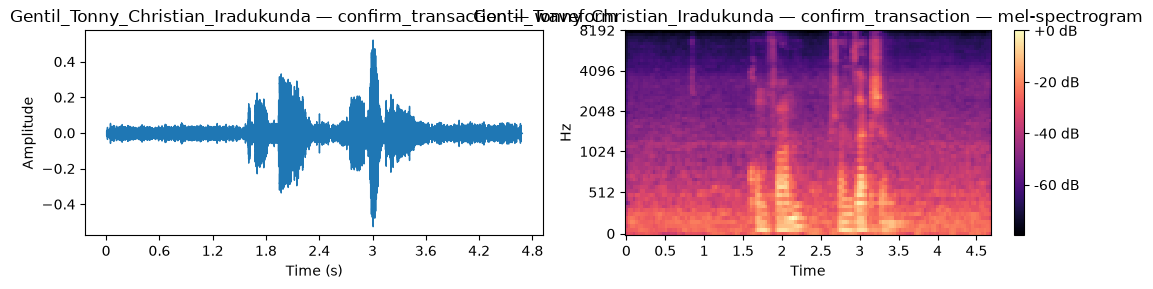

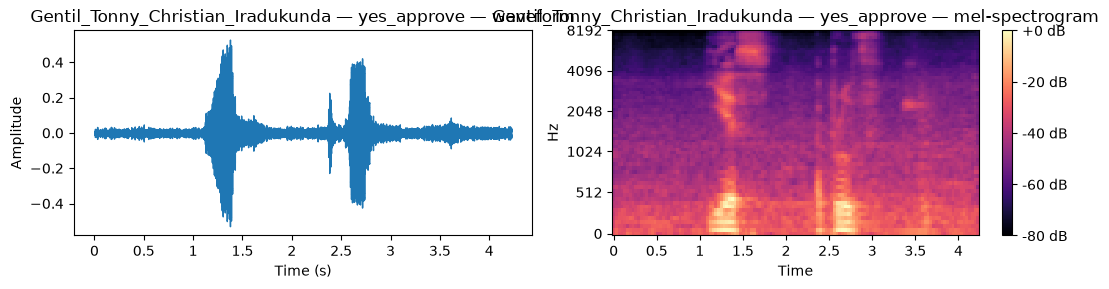

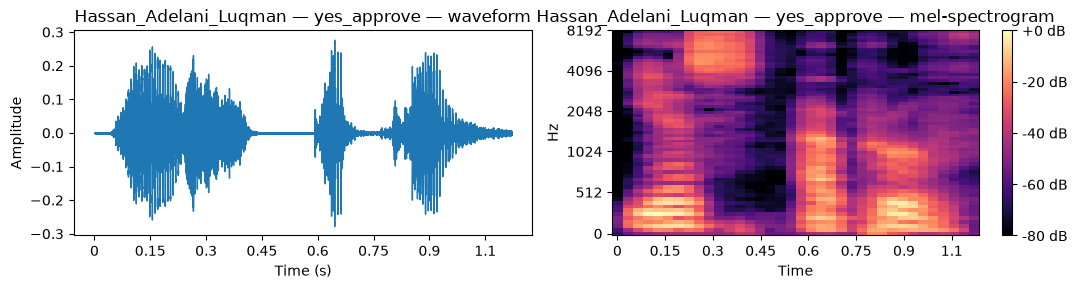

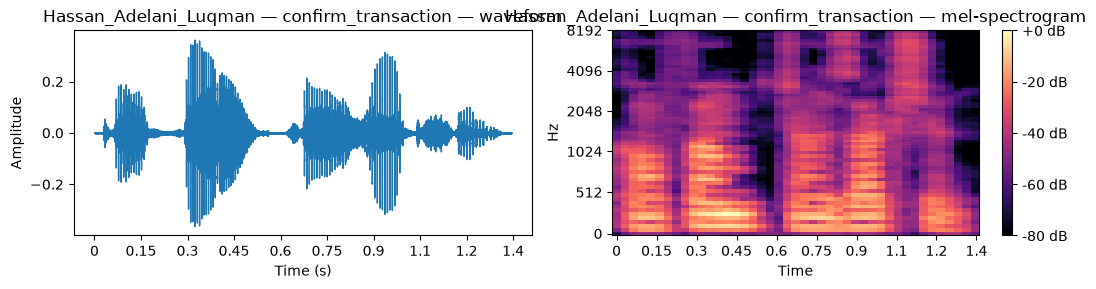

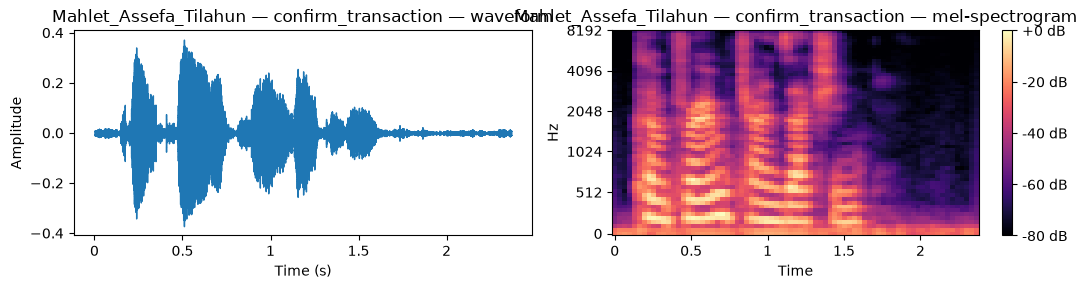

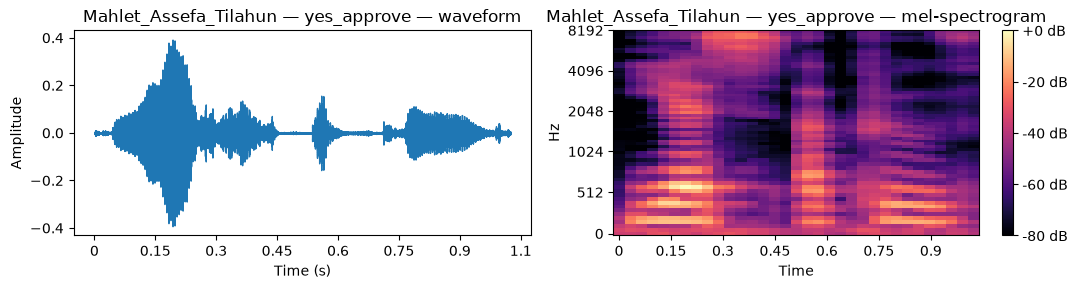

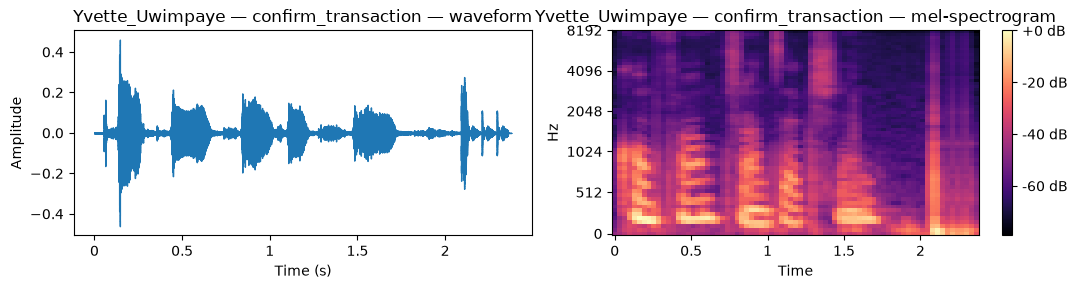

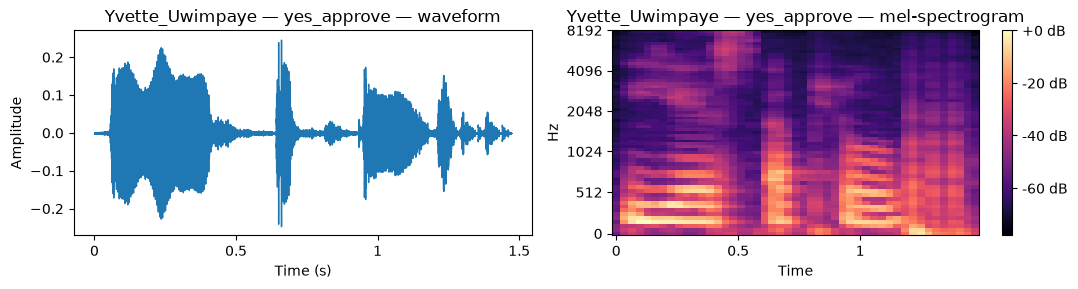

In [2]:
def show_clip(path):
    member = path.parent.name
    phrase = detect_phrase(path.stem)
    y = load_clip(path)
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=64)
    S_db = librosa.power_to_db(S, ref=np.max)

    fig, ax = plt.subplots(1, 2, figsize=(11, 3))
    librosa.display.waveshow(y, sr=SR, ax=ax[0])
    ax[0].set(title=f'{member} — {phrase} — waveform',
              xlabel='Time (s)', ylabel='Amplitude')
    img = librosa.display.specshow(S_db, sr=SR, x_axis='time', y_axis='mel', ax=ax[1])
    ax[1].set(title=f'{member} — {phrase} — mel-spectrogram')
    fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
    plt.tight_layout(); plt.show()

for c in clips:
    show_clip(c)

### Interpretation

Every clip is **loudness-normalized** before analysis, so the waveforms all reach a
similar amplitude and the model can't cheat by keying on how loud a recording happened
to be — it has to use the *shape* of the voice. In the waveforms you can still see the
two words of each phrase as two bursts separated by a quiet gap (leading/trailing
silence is trimmed first). The spectrograms concentrate energy in the lower bands with
faint horizontal harmonics — the signature of voiced speech — but the speakers differ
in *where* that energy sits: Hassan's spectra are the brightest (spectral centroid
~2040 Hz, roll-off ~3500 Hz), Gentil's the darkest (~1205 Hz), with Yvette (~1330 Hz)
and Mahlet in between, and Mahlet keeps the most negative first MFCC. Those per-speaker
differences in spectral shape are exactly what the MFCCs (and their deltas) capture,
and what the voiceprint model uses to tell the four members apart.

## 3. What augmentation does

We create at least two augmented copies per clip — **pitch shift**, **time stretch**,
and **added noise** — to expand our tiny dataset without changing *who* is speaking.
Below, one clip before vs. after each augmentation.

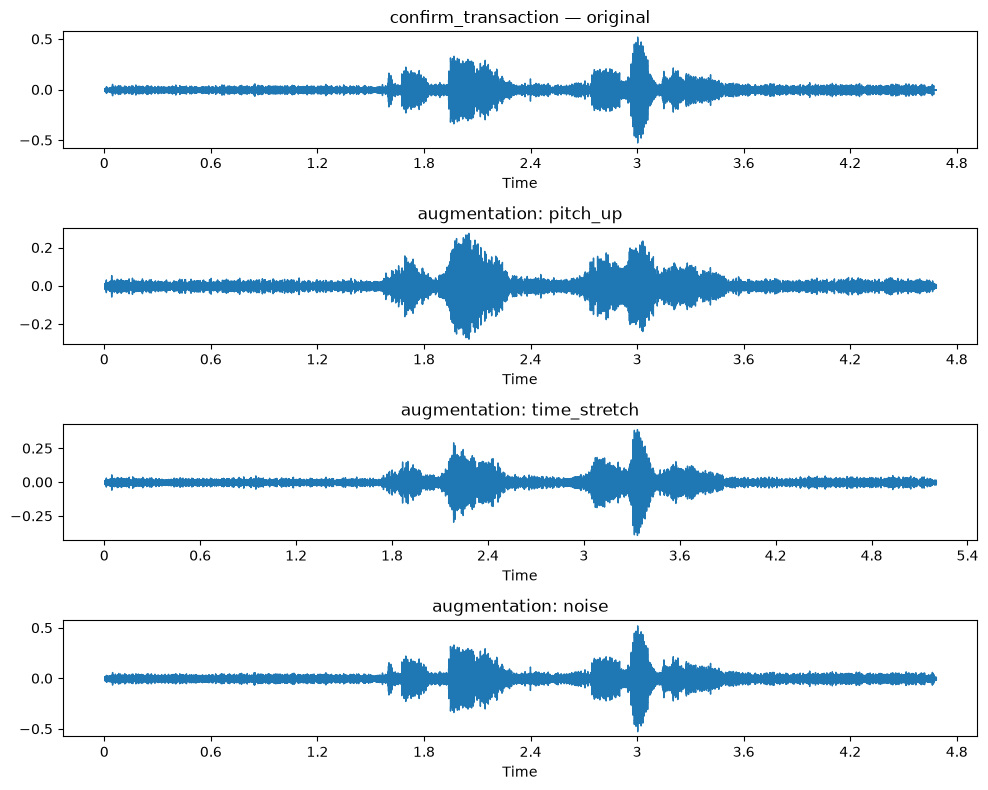

In [3]:
demo = clips[0]
y = load_clip(demo)
variants = augment(y, SR)

fig, ax = plt.subplots(len(variants) + 1, 1, figsize=(10, 2.0 * (len(variants) + 1)))
librosa.display.waveshow(y, sr=SR, ax=ax[0]); ax[0].set(title=f'{demo.stem} — original')
for i, (name, y_aug) in enumerate(variants.items(), start=1):
    librosa.display.waveshow(y_aug, sr=SR, ax=ax[i]); ax[i].set(title=f'augmentation: {name}')
plt.tight_layout(); plt.show()

### Interpretation

_Describe the effect:_ pitch shift raises/lowers the harmonic bands, time stretch
makes the same words take longer (waveform spreads out), and noise adds a fuzzy
floor. None of them change the speaker's identity — that's the point.

## 4. Feature extraction preview

`extract_features` turns each (possibly augmented) clip into a single row of numbers:
13 MFCCs plus their 1st- and 2nd-order **deltas** (mean + std for each = 78 values),
then spectral roll-off, RMS energy, zero-crossing rate, and spectral centroid (mean +
std each). The deltas describe how the voice *changes* over time, which helps separate
speakers beyond their average spectrum. Here is what one clip becomes.

In [4]:
feats = extract_features(load_clip(clips[0]), SR)
pd.Series(feats).to_frame('value').head(len(FEATURE_COLUMNS))

,value
mfcc_1_mean,-258.001190
mfcc_1_std,51.175335
mfcc_2_mean,137.101913
mfcc_2_std,25.428902
mfcc_3_mean,3.362584
...,...
rms_std,0.032591
zcr_mean,0.060992
zcr_std,0.035186
centroid_mean,1081.802221


## 5. Build the full feature table

This is the same call the script makes. It writes `data/processed/audio_features.csv`
(originals + augmentations), which the model reads. Every augmented row keeps its
parent's `source_clip_id` so the training split never separates a clip from its copies.

In [5]:
from audio_features import build_table
df = build_table(save_aug=True)
print('shape:', df.shape)
df.head()

Processed 8 source clip(s) -> 32 rows (24 augmented).
shape: (32, 91)


,member,phrase,source_clip_id,variant,augmented,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,...,mfcc_delta2_13_mean,mfcc_delta2_13_std,rolloff_mean,rolloff_std,rms_mean,rms_std,zcr_mean,zcr_std,centroid_mean,centroid_std
0,Gentil_Tonny_Christian_Iradukunda,confirm_transaction,Gentil_Tonny_Christian_Iradukunda__confirm_tra...,original,False,-258.001190,51.175335,137.101913,25.428902,3.362584,...,-0.019825,0.698298,2237.085459,889.964461,0.037759,0.032591,0.060992,0.035186,1081.802221,384.520252
1,Gentil_Tonny_Christian_Iradukunda,confirm_transaction,Gentil_Tonny_Christian_Iradukunda__confirm_tra...,pitch_up,True,-283.499664,51.450058,129.695129,23.854000,5.272880,...,-0.033222,0.613659,2418.792517,884.750004,0.026240,0.021911,0.066253,0.036918,1163.014100,377.454964
2,Gentil_Tonny_Christian_Iradukunda,confirm_transaction,Gentil_Tonny_Christian_Iradukunda__confirm_tra...,time_stretch,True,-294.025452,52.173332,136.162567,24.525616,4.633637,...,0.014549,0.721038,2225.699770,831.166104,0.025911,0.021902,0.062536,0.036910,1076.525369,353.092161
3,Gentil_Tonny_Christian_Iradukunda,confirm_transaction,Gentil_Tonny_Christian_Iradukunda__confirm_tra...,noise,True,-204.332257,33.920292,80.666049,19.160510,31.531145,...,-0.013036,0.574169,4931.813350,1153.298612,0.038267,0.032340,0.116766,0.042057,2053.471842,448.446616
4,Gentil_Tonny_Christian_Iradukunda,yes_approve,Gentil_Tonny_Christian_Iradukunda__yes_approve,original,False,-279.348053,52.004871,125.053688,31.325821,-0.752655,...,0.005056,0.527680,2737.077068,1259.623233,0.030381,0.039467,0.090963,0.081717,1328.180617,675.958954


### Class balance (rows per member)

In [6]:
df['member'].value_counts()

member
Gentil_Tonny_Christian_Iradukunda    8
Hassan_Adelani_Luqman                8
Mahlet_Assefa_Tilahun                8
Yvette_Uwimpaye                      8
Name: count, dtype: int64

## 6. Split methodology (why our accuracy is honest)

With only ~8 real clips, a random split would leak: an augmented copy is almost
identical to its original. We therefore **train on the "Yes, approve" clips and test
on the "Confirm transaction" clips** — a whole clip and all its augmentations stay on
one side, and testing on a *different phrase* means the model must recognise the
person, not the words (text-independent speaker verification).

Run the model in a terminal:
```bash
python scripts/train_voice_model.py
```
It saves `models/voice_model.joblib` and writes `results/metrics/voiceprint.json`. The
script reports the phrase-held-out accuracy / F1 / log-loss as the headline **and** a
leave-one-clip-out cross-validation mean±std, so the small-sample variance is visible
rather than hidden behind one lucky split. **Limitation to note in the report:** n is
tiny (8 clips), so treat the numbers as indicative, not definitive — the single biggest
improvement would be more recordings per member, not more feature engineering.